# 03.01 — MtM Hedging

#### Hedging error & convergence rate

For a delta‑hedged short call, the one‑step error over $\Delta t$ is

$$
\mathrm{PnL}_{t_i\to t_{i+1}} =
\underbrace{C(t_{i+1})-C(t_i)}_{\text{option change}}
- \underbrace{\Delta_i(S_{t_{i+1}}-S_{t_i})}_{\text{hedge gain}}
- r\bigl[C(t_i)-\Delta_i S_{t_i}\bigr]\Delta t .
$$

For small $\Delta t$, and, $\frac{\Delta S}{S} \approx \sigma\sqrt{\Delta t}\,\varepsilon$ with $\varepsilon\sim\mathcal{N}(0,1)$, this is dominated by gamma:

$$
\mathrm{PnL} \;\approx\; \frac12 \Gamma_i S_i^2 \Bigl[\bigl(\tfrac{\Delta S}{S}\bigr)^2 - \sigma^2\Delta t\Bigr] \;\approx\; \frac12 \Gamma_i S_i^2 \,\sigma^2\Delta t\,(\varepsilon^2-1).
$$

From (1) and $\mathbb{E}[\varepsilon^2]=1$, $\operatorname{Var}(\varepsilon^2)=2$:

$$
\mathbb{E}[\mathrm{PnL}] \approx \frac12 \Gamma_i S_i^2 \,\sigma^2\Delta t\,\mathbb{E}[\varepsilon^2-1] = 0 .
$$

Hence $\operatorname{Var}(\mathrm{PnL}) = \mathbb{E}[\mathrm{PnL}^2] - (\mathbb{E}[\mathrm{PnL}])^2 = \mathbb{E}[\mathrm{PnL}^2]$.

$$
\begin{aligned}
\operatorname{Var}(\mathrm{PnL})
&\approx \Bigl(\frac12 \Gamma_i S_i^2 \sigma^2\Delta t\Bigr)^2 \mathbb{E}[(\varepsilon^2-1)^2] \\
&= \Bigl(\frac12 \Gamma_i S_i^2 \sigma^2\Delta t\Bigr)^2 \cdot 2
\;\propto\; (\Delta t)^2 .
\end{aligned}
$$


With $n$ rebalancing steps, total time $T = n\Delta t$. Assuming uncorrelated errors, the variance of the terminal P&L sums:

$$
\operatorname{Var}(\text{Terminal PnL})
\approx \sum_{i=0}^{n-1} \operatorname{Var}(\mathrm{PnL}_i)
\propto n \cdot (\Delta t)^2
= n\cdot\frac{T^2}{n^2} = \frac{T^2}{n}.
$$

Since $T$ is **fixed**, the only variable part is $1/n$. Thus

$$
\operatorname{Var}(\text{Terminal PnL}) = O\Bigl(\frac{1}{n}\Bigr),
\qquad
\operatorname{Std}(\text{Terminal PnL}) = O\Bigl(\frac{1}{\sqrt{n}}\Bigr).
$$



In [1]:
# ── setup: regimes · hedge legs · training · plots ───────────────────────────
import math
from types import SimpleNamespace as NS
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
import sys, os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)
torch.set_num_threads(4)
sns.set_theme(style="whitegrid")

import qabit as qb

# ── factor / system / market / product API (the modern, factor-based stack) ──
from qabit import (
    SDESystem,
    GeometricBrownianFactor,
    ConstantRateFactor,
    VasicekRateFactor,
    EventCalendar,
    Stock,
    EuropeanOption,
    Market,
    DiscountCurve,
    VolSurface,
)
from qabit.core.market.curve import (
    StochasticDiscountCurve,
    StochasticHazardCurve,
    MarketKeys,
)
from qabit.core.nn import (
    DeepHedger,
    HedgingMLP,
    FeatureSet,
    Moneyness,
    TimeToMaturity,
    InstantaneousVol,
    ShortRate,
    HazardRate,
    Survival,
    PrevHoldings,
    FixedHedge,
    ResetHedge,
    VarianceLoss,
    KnockOutLiveness,
    CliquetLiveness,
    MortalityLiveness,
)

# palette (shared by the MtM-hedging panels below)
BLUE, ORANGE, GREEN = "#378ADD", "#D85A30", "#1D9E75"


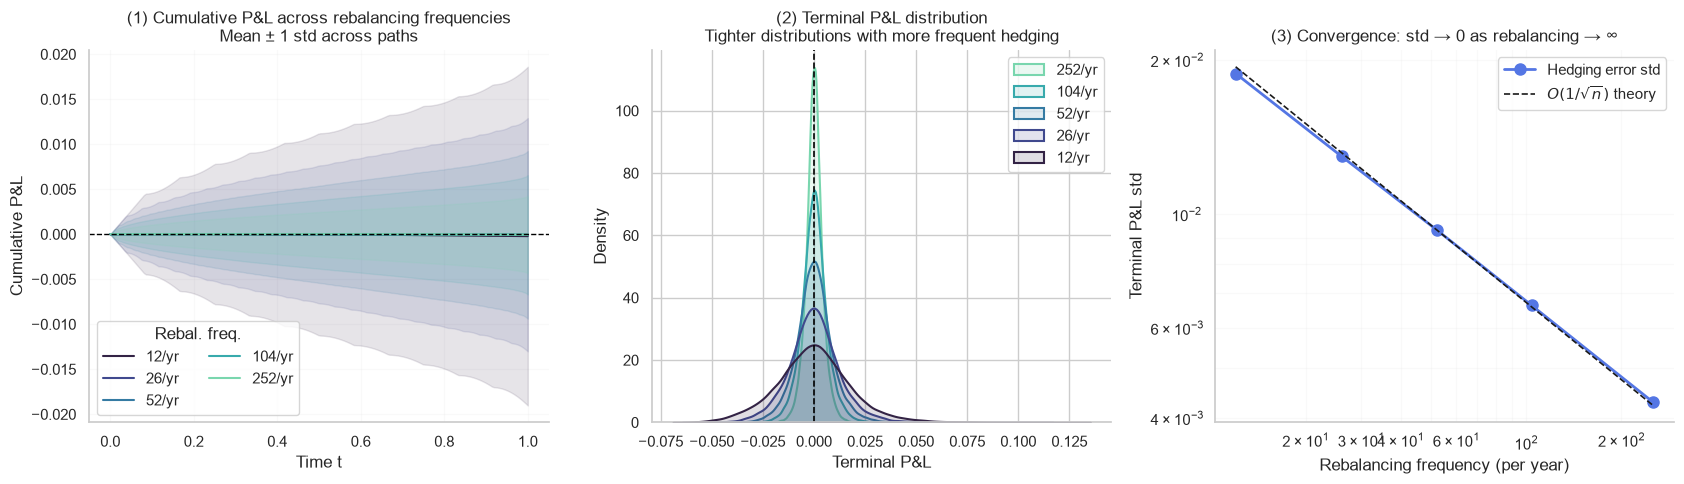

In [2]:
# ── Common simulation parameters ─────────────────────────────────────────────
S0, K, r, sigma, T = 1.0, 1.0, 0.05, 0.20, 1.0
N_PATHS = 50_000
N_REBAL = 252
time_grid = list(np.linspace(0., T, N_REBAL + 1))

# Frequencies shown in the first two panels (declared up front so the calendar
# can carry every rebalancing date as an *exact* entry — no searchsorted snap).
display_freqs = [12, 26, 52, 104, 252]

# One simulation, one calendar.  The flat-rate world is a single GBM factor with
# constant drift μ = r (rate=None ⇒ no rate factor); SDESystem replaces the old
# CorrelatedProcesses engine.  Build the calendar as the union of the fine grid
# and all rebalancing dates so each hedge date is an exact column of the path.
reb_union = np.unique(np.concatenate([np.linspace(0., T, n + 1) for n in display_freqs]))
cal_dates = np.union1d(np.asarray(time_grid), reb_union)
cal = EventCalendar(torch.as_tensor(cal_dates, dtype=torch.float64))

gbm = GeometricBrownianFactor(sigma=sigma, s0=S0, mu=r, rate=None)
sde = SDESystem({'eq': gbm})
sde.simulate(cal, N_PATHS, seed=42)
S = Stock(sde['eq'])
S_state = sde['eq'].get_state()

mkt = Market(
    discount   = {'ois': DiscountCurve.flat(r)},
    volatility = {'v':   VolSurface.flat(sigma, K_min=0.3, K_max=3., T_max=2.)},
)

call = EuropeanOption(S, K, T, is_call=True)
put  = EuropeanOption(S, K, T, is_call=False)

# ── Build MTM and delta grids — shape (T_val, N) ──────────────────────────────
call_prices = call.price(mkt, time_grid)
put_prices  = put.price(mkt, time_grid)
call_deltas = call.delta(mkt, time_grid)
put_deltas  = put.delta(mkt, time_grid)


# ----------------------------------------------------------------------
# Colours / accumulators for the display frequencies (see display_freqs above)
# ----------------------------------------------------------------------
colors = sns.color_palette("mako", len(display_freqs))
t_common = np.linspace(0, T, 200)          # dense time grid for interpolation
terminal_pnls = {}                         # store terminal P&L per frequency
cum_pnl_interp = {}                        # store interpolated cumulative P&L per frequency

# ----------------------------------------------------------------------
# Compute P&L for every display frequency and collect statistics
# ----------------------------------------------------------------------
for n_reb, col in zip(display_freqs, colors):
    # Rebalancing dates and instruments
    r_dates = np.linspace(0.0, T, n_reb + 1)
    dt = T / n_reb
    c_grid = call.price(mkt, r_dates)                        # (n_reb+1, N)
    d_grid = torch.stack([call.delta(mkt, t) for t in r_dates])  # (n_reb+1, N)
    reb_idx = np.searchsorted(cal_dates, r_dates)            # exact path columns
    S_grid = S_state.paths[:, reb_idx].T.float()             # (n_reb+1, N)

    # Hedging error per period
    dC = torch.diff(c_grid, dim=0)                           # (n_reb, N)
    dS = torch.diff(S_grid, dim=0)                           # (n_reb, N)
    B  = c_grid[:-1] - d_grid[:-1] * S_grid[:-1]             # cash balance
    pnl_period = dC - d_grid[:-1] * dS - r * B * dt
    cum = pnl_period.cumsum(dim=0)                           # (n_reb, N)

    # Store terminal P&L
    terminal_pnls[n_reb] = cum[-1].numpy()

    # -------- Fix: Prepend zero cumulative P&L at time 0 ----------
    times_orig = r_dates[1:]                                 # times of rebal steps (first is dt)
    cum_np = cum.numpy()                                     # shape (n_reb, N)
    # Add time 0 with zero P&L for every path
    times_full = np.concatenate([[0.0], times_orig])
    cum_full = np.concatenate([np.zeros((1, cum_np.shape[1])), cum_np], axis=0)

    # Interpolate onto common time grid (no extrapolation needed because 0 and T are in range)
    interp_func = interp1d(times_full, cum_full, axis=0,
                           kind='linear', fill_value='extrapolate')
    cum_interp = interp_func(t_common)                       # (len(t_common), N)
    cum_pnl_interp[n_reb] = cum_interp
    

# ----------------------------------------------------------------------
# Create the 1×3 figure
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# -------- Panel 1: Cumulative P&L mean ± std for each frequency --------
ax1 = axes[0]
for n_reb, col in zip(display_freqs, colors):
    cum = cum_pnl_interp[n_reb]                        # (time, paths)
    mean = cum.mean(axis=1)
    std  = cum.std(axis=1)
    ax1.plot(t_common, mean, color=col, label=f'{n_reb}/yr')
    ax1.fill_between(t_common, mean - std, mean + std,
                     color=col, alpha=0.12)
ax1.axhline(0, color='black', lw=1, ls='--')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Cumulative P&L')
ax1.set_title('(1) Cumulative P&L across rebalancing frequencies\nMean ± 1 std across paths')
ax1.legend(title='Rebal. freq.', ncol=2, frameon=True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, alpha=0.1)

# -------- Panel 2: Terminal P&L distributions (KDE overlaid) --------
ax2 = axes[1]
for n_reb, col in zip(reversed(display_freqs), reversed(colors)):
    sns.kdeplot(terminal_pnls[n_reb], ax=ax2, color=col, fill=True,
                alpha=0.15, linewidth=1.5, label=f'{n_reb}/yr')
ax2.axvline(0, color='black', lw=1.2, ls='--')
ax2.set_xlabel('Terminal P&L')
ax2.set_ylabel('Density')
ax2.set_title('(2) Terminal P&L distribution\nTighter distributions with more frequent hedging')
ax2.legend(frameon=True)
ax2.spines[['top', 'right']].set_visible(False)

# -------- Panel 3: Convergence of std vs frequency --------
ax3 = axes[2]
freqs = np.array(list(terminal_pnls.keys()))
stds  = np.array([terminal_pnls[n].std() for n in freqs])
ax3.loglog(freqs, stds, 'o-', color="#5476E4", lw=2, ms=8,
           label='Hedging error std')
# Theoretical O(1/√n) reference
idx_ref = 2
ref_scale = stds[idx_ref] * np.sqrt(freqs[idx_ref])
ax3.loglog(freqs, ref_scale / np.sqrt(freqs), 'k--', lw=1.2,
           label='$O(1/\\sqrt{n})$ theory')
ax3.set_xlabel('Rebalancing frequency (per year)')
ax3.set_ylabel('Terminal P&L std')
ax3.set_title('(3) Convergence: std → 0 as rebalancing → ∞')
ax3.legend(frameon=True)
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(True, which='both', alpha=0.1)

plt.tight_layout()
# plt.savefig('pnl_multi_rebal.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Stochastic rates — the hedging error a flat-rate delta misses

So far the short rate has been the constant `r`. Real desks quote and hedge with a
flat-rate Black–Scholes delta, yet the financing account accrues at whatever the
*realised* short rate turns out to be. We can make that mismatch explicit with a
single `SDESystem`, swapping **only** the rate factor:

* **Deterministic world** — `ConstantRateFactor(r)`: the cash account grows at
  exactly the rate the delta assumes. The only replication error is the familiar
  gamma / discretisation term, which vanishes as $O(1/\sqrt{n})$.
* **Stochastic world** — `VasicekRateFactor`, correlated with the equity: the cash
  account now drifts with $r_t$ and the option's true rate sensitivity ($\rho$) is
  left unhedged.

Because `ConstantRateFactor` contributes **zero** Brownian drivers, both worlds share
the *same* equity dynamics and API — the only change is the rate factor and the
correlation matrix. The per-step replication P&L is

$$\mathrm{PnL}_{t_i\to t_{i+1}} = \big(C_{i+1}-C_i\big) - \Delta_i\,(S_{i+1}-S_i)
   - B_i\Big(e^{\int_{t_i}^{t_{i+1}} r_s\,ds}-1\Big),\qquad B_i = C_i-\Delta_i S_i,$$

identical to the constant-rate formula above except the cash leg compounds at the
*path-wise* short rate (trapezoidal $\int r\,ds$, the same quadrature the discount
curve uses). The diff between the two worlds isolates the interest-rate risk — and,
as panel (2) shows, that risk is **invariant to how often you delta-rebalance**.

rate-risk floor sqrt(stoch^2 - det^2), ~frequency-invariant: [0.00507 0.00455 0.00522 0.00536 0.00553 0.00571 0.00571]


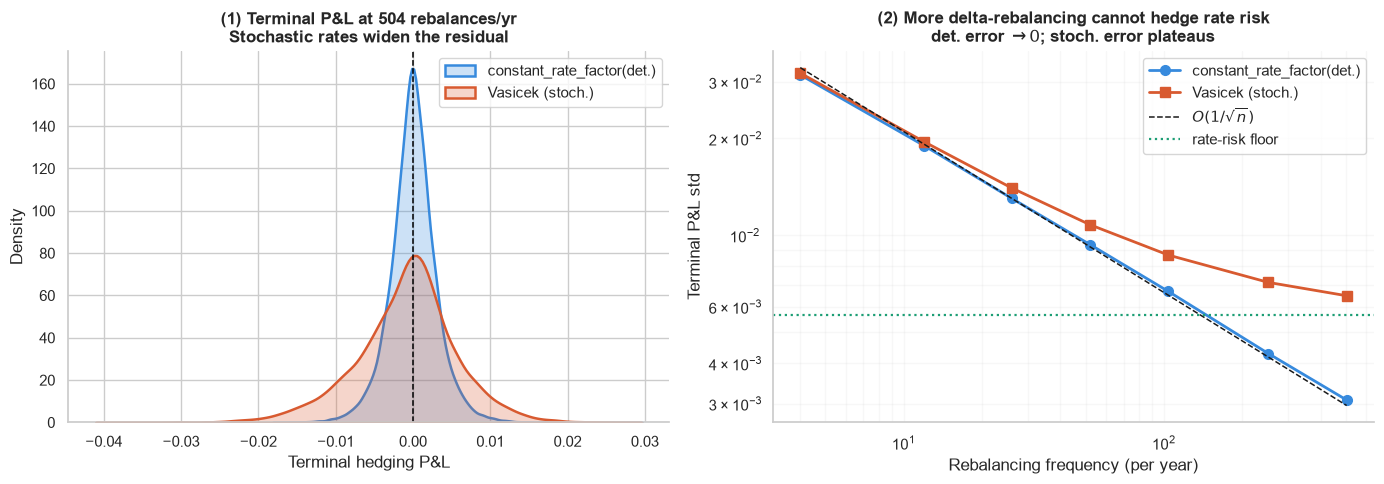

 freq |   det std | stoch std | rate risk
    4 |   0.03153 |   0.03194 |   0.00507
   12 |   0.01898 |   0.01951 |   0.00455
   26 |   0.01302 |   0.01403 |   0.00522
   52 |   0.00936 |   0.01079 |   0.00536
  104 |   0.00669 |   0.00868 |   0.00553
  252 |   0.00429 |   0.00714 |   0.00571
  504 |   0.00308 |   0.00649 |   0.00571


In [3]:
# ── Two worlds, identical equity dynamics, only the rate factor changes ───────
# Vasicek mean = r  ⇒  no drift bias; the residual is pure rate *volatility* risk.
kappa_r, sigma_r, rho_Sr = 0.6, 0.02, -0.30
N_FINE = 504

def build_world(rate_factor, correlation, seed=42, n_paths=30_000):
    # One SDESystem, two named factors.  ConstantRateFactor carries no Brownian
    # driver, so swapping it for VasicekRateFactor is the *only* change between
    # the two worlds — same equity factor, same seed, same calendar.
    sysm = SDESystem(
        {'rate':   rate_factor,
         'equity': GeometricBrownianFactor(sigma=sigma, s0=S0, rate='rate')},
        correlation=correlation)
    cal = EventCalendar.from_horizon(T, dt=T / N_FINE)
    sysm.simulate(cal, n_paths, seed=seed)
    return sysm, cal.as_tensor(dtype=torch.float32)

def _Phi(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

def bsm_price_delta(S, tau, r_hedge, vol):
    # Flat-rate Black-Scholes call price & delta (the trader's model).
    if tau <= 1e-12:
        return (S - K).clamp(min=0.0), (S > K).float()
    st = math.sqrt(tau)
    d1 = (torch.log(S / K) + (r_hedge + 0.5 * vol**2) * tau) / (vol * st)
    C  = S * _Phi(d1) - K * math.exp(-r_hedge * tau) * _Phi(d1 - vol * st)
    return C, _Phi(d1)

def hedge_terminal_pnl(sysm, dates, n_reb, r_hedge, vol):
    # Terminal replication P&L of a flat-rate delta hedge; the cash leg
    # compounds at the realised path-wise short rate.
    reb = np.unique(np.linspace(0, len(dates) - 1, n_reb + 1).astype(int))
    S_all = sysm['equity'].get_state().paths     # (N, E)
    r_all = sysm['rate'].get_state().paths        # (N, E)
    cum = torch.zeros(S_all.shape[0])
    for a, b in zip(reb[:-1], reb[1:]):
        S_a, S_b = S_all[:, a], S_all[:, b]
        C_a, D_a = bsm_price_delta(S_a, T - float(dates[a]), r_hedge, vol)
        C_b, _   = bsm_price_delta(S_b, T - float(dates[b]), r_hedge, vol)
        B_a = C_a - D_a * S_a                            # cash leg
        seg = r_all[:, a:b + 1]
        seg_dt = (dates[a + 1:b + 1] - dates[a:b]).to(seg.dtype)
        integ = (0.5 * (seg[:, :-1] + seg[:, 1:]) * seg_dt).sum(dim=1)   # ∫ r ds
        cum = cum + ((C_b - C_a) - D_a * (S_b - S_a) - B_a * (torch.exp(integ) - 1.0))
    return cum

det_sys, det_grid = build_world(ConstantRateFactor(r), correlation=None, seed=42)
sto_sys, sto_grid = build_world(
    VasicekRateFactor(kappa_r, r, sigma_r, r),
    correlation=np.array([[1.0, rho_Sr], [rho_Sr, 1.0]]), seed=42)

reb_freqs = [4, 12, 26, 52, 104, 252, 504]
det_std, sto_std, rate_risk = [], [], []
for n in reb_freqs:
    pd_ = hedge_terminal_pnl(det_sys, det_grid, n, r, sigma)
    ps_ = hedge_terminal_pnl(sto_sys, sto_grid, n, r, sigma)
    det_std.append(float(pd_.std()))
    sto_std.append(float(ps_.std()))
    rate_risk.append(math.sqrt(max(sto_std[-1]**2 - det_std[-1]**2, 0.0)))

pnl_det_dense = hedge_terminal_pnl(det_sys, det_grid, 504, r, sigma).numpy()
pnl_sto_dense = hedge_terminal_pnl(sto_sys, sto_grid, 504, r, sigma).numpy()
print('rate-risk floor sqrt(stoch^2 - det^2), ~frequency-invariant:',
      np.round(rate_risk, 5))

# ── Visualise: distribution widening + the rate-risk floor ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.kdeplot(pnl_det_dense, ax=ax, fill=True, alpha=0.25, lw=1.8,
            color=BLUE,   label='constant_rate_factor(det.)')
sns.kdeplot(pnl_sto_dense, ax=ax, fill=True, alpha=0.25, lw=1.8,
            color=ORANGE, label='Vasicek (stoch.)')
ax.axvline(0, color='black', lw=1.1, ls='--')
ax.set_xlabel('Terminal hedging P&L'); ax.set_ylabel('Density')
ax.set_title('(1) Terminal P&L at 504 rebalances/yr\n'
             'Stochastic rates widen the residual', fontweight='bold')
ax.legend(frameon=True); ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
f = np.array(reb_freqs)
ax.loglog(f, det_std, 'o-', color=BLUE,   lw=2, ms=7, label='constant_rate_factor(det.)')
ax.loglog(f, sto_std, 's-', color=ORANGE, lw=2, ms=7, label='Vasicek (stoch.)')
ref = det_std[2] * math.sqrt(f[2])
ax.loglog(f, ref / np.sqrt(f), 'k--', lw=1.1, label=r'$O(1/\sqrt{n})$')
ax.axhline(float(np.mean(rate_risk[-3:])), color=GREEN, lw=1.6, ls=':',
           label='rate-risk floor')
ax.set_xlabel('Rebalancing frequency (per year)')
ax.set_ylabel('Terminal P&L std')
ax.set_title('(2) More delta-rebalancing cannot hedge rate risk\n'
             r'det. error $\to 0$; stoch. error plateaus', fontweight='bold')
ax.legend(frameon=True); ax.grid(True, which='both', alpha=0.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

print(f"{'freq':>5} | {'det std':>9} | {'stoch std':>9} | {'rate risk':>9}")
for n, d, s, rr in zip(reb_freqs, det_std, sto_std, rate_risk):
    print(f"{n:>5} | {d:>9.5f} | {s:>9.5f} | {rr:>9.5f}")


# 03.02 — Deep Hedging Across Regimes

A single neural hedging policy — an MLP reading a small feature set, trained directly on
simulated paths by a variance loss over a ladder of re-struck options — learns the
correct hedge for vanilla **and** exotic payoffs, across three market regimes of
increasing realism, with no analytic Greeks supplied.

- **R1** — flat rate, flat vol (controlled baseline)
- **R2** — Vasicek stochastic rate, flat vol
- **R3** — Vasicek rate **and** Heston stochastic vol (realistic world)

> The deep-hedge budgets below (`FAST=False`) are the ones at which the book delta
> matches closed forms; they take time on CPU. Set `FAST=True` for recognizable-but-
> unconverged shapes in minutes.

In [ ]:
def make_regime(
    name, equity="gbm", rate="flat", hazard=None, sigma=0.20, r=0.03, s0=1.0
):
    """A simulated world: SDE system + the market that prices against it."""
    f = {
        "rate": qb.ConstantRateFactor(rate=r)
        if rate == "flat"
        else qb.VasicekRateFactor(kappa=0.5, theta=r, sigma=0.01, r0=r)
    }
    if equity == "gbm":
        f["eq"] = qb.GeometricBrownianFactor(sigma=sigma, s0=s0, rate="rate")
    else:
        f["eq"] = qb.HestonFactor(
            kappa=2.0,
            theta=sigma**2,
            xi=0.30,
            rho=-0.7,
            s0=s0,
            v0=sigma**2,
            rate="rate",
        )
    if hazard:
        f["mort"] = (
            qb.GompertzHazardFactor(m=80.0, b=9.5, entry_age=60.0)
            if hazard == "det"
            else qb.CIRGompertzHazardFactor(
                m=80.0, b=9.5, entry_age=60.0, kappa=0.5, sigma_lam=0.03
            )
        )
    sde = qb.SDESystem(f)
    market = qb.Market(
        discount={
            "ois": qb.DiscountCurve.flat(r)
            if rate == "flat"
            else StochasticDiscountCurve(sde["rate"])
        },
        volatility={"v": qb.VolSurface.flat(sigma)},
        hazard={"mort": StochasticHazardCurve(sde["mort"])} if hazard else {},
    )
    bits = [f"{rate} rate", "heston vol" if equity == "heston" else "flat vol"]
    if hazard:
        bits.append(f"{hazard} hazard")
    return NS(
        name=name,
        system=sde,
        market=market,
        stock=qb.Stock(sde["eq"], cost=0.0),
        fund=sde["eq"],
        sigma=sigma,
        r=r,
        hazard=hazard,
        label=f"{name} · " + " / ".join(bits),
    )


def make_legs(
    stock, *, tenor=10 / 252, cost=0.0, puts=(("ATM put", 1.00), ("ITM put", 1.05))
):
    """Hedge ladder: the underlying + re-struck puts (strike = alpha·S_t)."""
    legs, labels = [FixedHedge(stock, cost=cost)], ["stock"]
    for lab, alpha in puts:

        def make_inner(level, t0, _th=tenor):
            return qb.EuropeanOption(
                stock, strike=level, maturity=t0 + _th, is_call=False, cost=cost
            )

        legs.append(ResetHedge(make_inner, stock, alpha=alpha, tenor=tenor, cost=cost))
        labels.append(lab)
    return legs, labels


def make_features(reg, n_legs, extra=()):
    feats = [Moneyness(), TimeToMaturity(), InstantaneousVol(), ShortRate()]
    if reg.hazard:
        feats += [HazardRate(), Survival()]
    feats += list(extra)
    feats.append(PrevHoldings(n_inst=n_legs))
    return FeatureSet(feats)


def hedge(
    reg,
    target,
    legs,
    feats,
    *,
    T,
    rebal_dt=1 / 252,
    sim_dt=None,
    tenor=10 / 252,
    n_paths=4096,
    n_epochs=150,
    lr=1e-3,
    seed=42,
    loss=None,
    liability=None,
    weight_fn=None,
    diag_paths=20_000,
    verbose=False,
    base_policy=None,
    liveness=None,
):
    """Train a DeepHedger on `target` and return everything the plots need.
    The current DeepHedger reads discount/underlier from the target's own MarketKeys
    and underlier; `liability=None` ⇒ the realized payoff is used."""
    cal = qb.EventCalendar.from_horizon(T + tenor, sim_dt or rebal_dt)
    rebal = torch.arange(0.0, T + 1e-9, rebal_dt)
    hed = DeepHedger(
        HedgingMLP(feats.total_dim, n_hedges=len(legs), seed=seed),
        feats,
        legs,
        loss or VarianceLoss(),
        liability=liability,
        base_policy=base_policy,
        liveness=liveness,
    )
    hed.fit(
        target,
        system=reg.system,
        calendar=cal,
        rebalance_dates=rebal,
        market=reg.market,
        n_paths=n_paths,
        n_epochs=n_epochs,
        lr=lr,
        seed=seed,
        path_weight_fn=weight_fn,
        verbose=verbose,
    )
    d = hed.diagnose(
        target,
        system=reg.system,
        calendar=cal,
        rebalance_dates=rebal,
        market=reg.market,
        n_paths=diag_paths,
        seed=seed + 777,
        path_weight_fn=weight_fn,
    )
    net = d["pnl"] - d["tc"]
    return NS(
        hedger=hed,
        diag=d,
        rebal=rebal,
        cal=cal,
        T=T,
        reg=reg,
        target=target,
        mean_pnl=float(net.mean()),
        var_kept=float(net.std() / d["liability"].std()) ** 2,
    )


# ── plotting ─────────────────────────────────────────────────────────────────
def binned(x, y, nb=40):
    e = np.quantile(x, np.linspace(0, 1, nb + 1))
    e[-1] += 1e-9
    i = np.clip(np.searchsorted(e, x, side="right") - 1, 0, nb - 1)
    keep = [b for b in range(nb) if (i == b).sum() > 10]
    return (
        np.array([x[i == b].mean() for b in keep]),
        np.array([y[i == b].mean() for b in keep]),
    )


def plot_time(res, labels, title=""):
    H = res.diag["holdings"]
    t = res.diag["open_times"] / res.T
    fig, axes = plt.subplots(
        1, H.shape[0], figsize=(4 * H.shape[0], 2.8), squeeze=False
    )
    for j, ax in enumerate(axes[0]):
        h = H[j].abs()
        ax.plot(t, h.mean(1), color="k")
        ax.fill_between(t, h.quantile(0.1, dim=1), h.quantile(0.9, dim=1), alpha=0.2)
        ax.set_title(labels[j], fontsize=9)
        ax.set_xlabel("t / T")
        ax.spines[["top", "right"]].set_visible(False)
    axes[0][0].set_ylabel("|holding|")
    fig.suptitle(title or res.reg.label, fontsize=10)
    fig.tight_layout()


def plot_vs(
    res,
    labels,
    x=None,
    xlabel="spot $S_t$",
    k=None,
    mask=None,
    mask_label="dead / knocked out",
    title="",
    ref=None,
):
    """Holdings per leg vs a state coordinate at one rebalance step `k`.
    `mask` splits paths into two cohorts; `ref(xgrid)->y` overlays an analytic book curve."""
    H = res.diag["holdings"]
    M = H.shape[1]
    k = M // 2 if k is None else k
    x = res.diag["spot_grid"][k].numpy() if x is None else np.asarray(x)
    alive = np.ones(len(x), bool) if mask is None else ~np.asarray(mask)
    fig, axes = plt.subplots(
        1, H.shape[0], figsize=(4 * H.shape[0], 2.9), squeeze=False
    )
    for j, ax in enumerate(axes[0]):
        h = H[j, k].numpy()
        ax.scatter(
            x[alive], h[alive], s=2, alpha=0.15, color="#4393c3", rasterized=True
        )
        if mask is not None and (~alive).sum() > 10:
            ax.scatter(
                x[~alive],
                h[~alive],
                s=2,
                alpha=0.3,
                color="#d6604d",
                label=mask_label if j == 0 else None,
                rasterized=True,
            )
        cx, cy = binned(x[alive], h[alive])
        ax.plot(cx, cy, color="k", lw=1.6)
        ax.set_title(labels[j], fontsize=9)
        ax.set_xlabel(xlabel)
        ax.set_xlim(np.quantile(x, 0.005), np.quantile(x, 0.995))
        ax.spines[["top", "right"]].set_visible(False)
    if ref is not None:
        g = np.linspace(*np.quantile(x[alive], [0.02, 0.98]), 120)
        axes[0][0].plot(g, ref(g), "r--", lw=1.2, label="analytic")
    if mask is not None or ref is not None:
        axes[0][0].legend(fontsize=7, markerscale=4)
    axes[0][0].set_ylabel("holding")
    t = float(res.diag["open_times"][k])
    fig.suptitle((title or res.reg.label) + f"   ·   t = {t:.3g}", fontsize=10)
    fig.tight_layout()


def summary_table(results):
    print(f"{'target':<12s}{'regime':<10s}{'var kept':>10s}{'E[pnl]':>10s}")
    for (tgt, rg), r in results.items():
        print(f"{tgt:<12s}{rg:<10s}{r.var_kept:>9.1%}{r.mean_pnl:>+10.4f}")


In [ ]:
# FAST=True runs in minutes (recognizable shapes); FAST=False is the converged budget.
FAST = False
BUDGET = (dict(n_paths=2048*2, n_epochs=40,  diag_paths=8_000) if FAST else
          dict(n_paths=2048*4, n_epochs=160, diag_paths=20_000))

REGIMES = {
    "R1": make_regime("R1"),                                   # flat rate / flat vol
    "R2": make_regime("R2", rate="vasicek"),                   # stoch rate / flat vol
    "R3": make_regime("R3", equity="heston", rate="vasicek"),  # stoch rate / stoch vol
}
results = {}

## European call — the policy learns `N(d₁)`

The sanity anchor: the book's spot profile should be the textbook delta. With the stock
in the ladder, the stock leg carries the delta and the puts stay small. As the regime
gets richer (R1 → R3) the policy reads its extra features and the holdings sharpen.

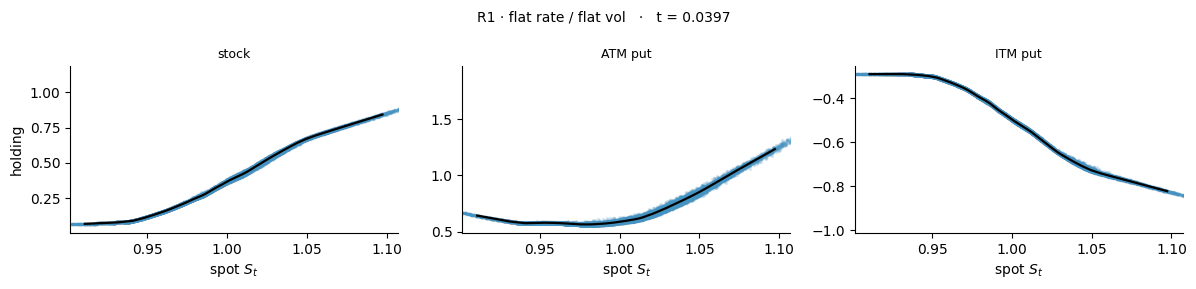

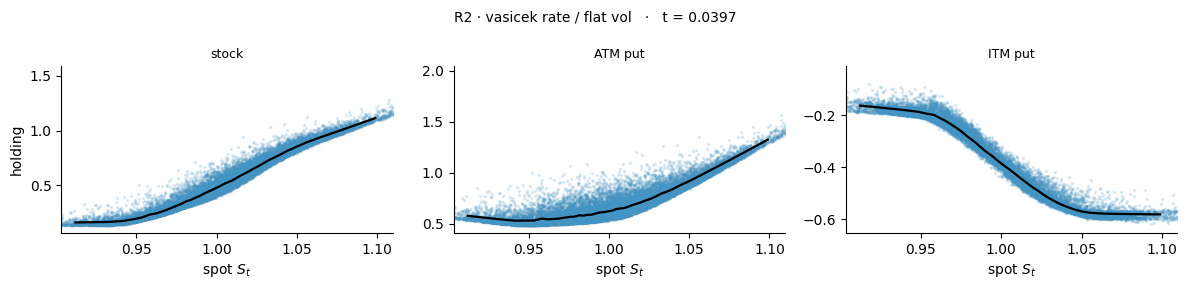

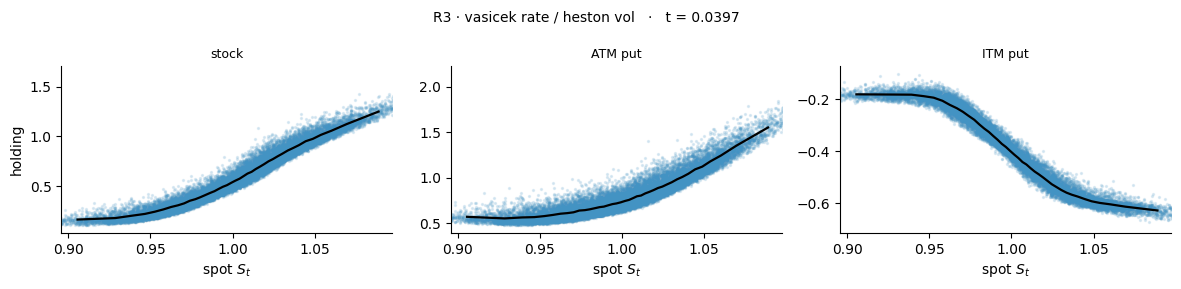

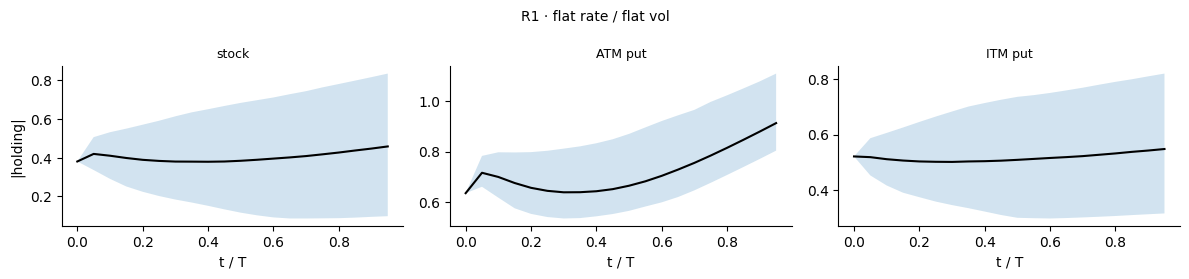

In [1]:
T = 20/252
for rg, reg in REGIMES.items():
    legs, labels = make_legs(reg.stock)
    tgt = qb.EuropeanOption(reg.stock, strike=1.0, maturity=T, is_call=True)
    res = hedge(reg, tgt, legs, make_features(reg, len(legs)), T=T, **BUDGET)
    results[("european", rg)] = res
    plot_vs(res, labels)
plot_time(results[("european", "R1")], labels)

## Up-and-out barrier (B = 1.10)

As spot approaches the barrier the option value collapses and the hedge **flips sign**.
Paths that have already knocked out carry no liability, so the policy holds them flat
(masked red) — a `BarrierBreached` feature plus `KnockOutLiveness` let it zero the dead
book. (The variance-optimal book deliberately shrinks the analytic RR-delta spike near
the barrier.)

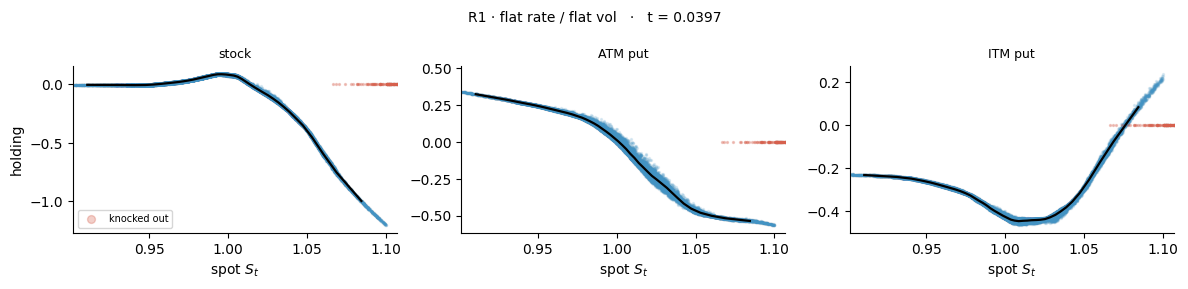

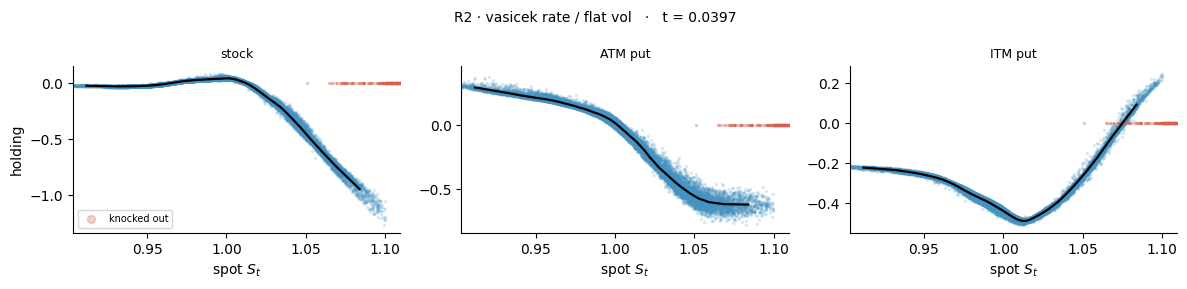

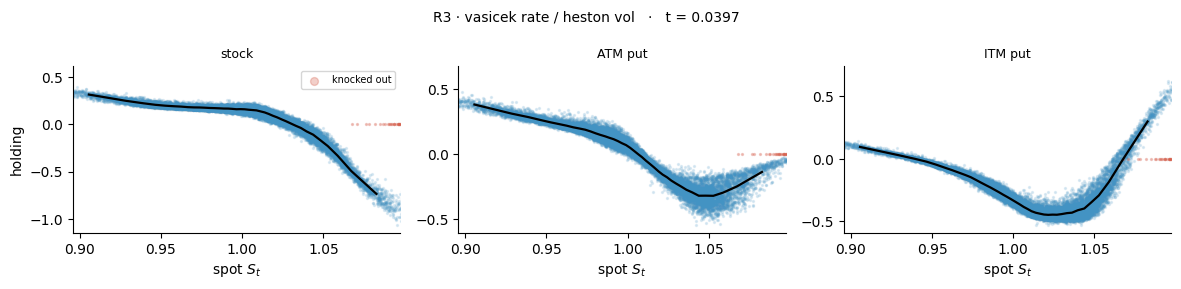

In [1]:
def breach_mask(res, B=1.10, k=None):
    H = res.diag["holdings"]; k = H.shape[1] // 2 if k is None else k
    S = res.reg.stock.full_path(); d = res.reg.stock._state().dates
    i = int(torch.searchsorted(d, res.diag["open_times"][k].to(d.dtype)))
    return (S[:, : i + 1].max(1).values >= B).numpy()

T = 20 / 252
from qabit.core.nn import BarrierBreached, KnockOutLiveness
for rg, reg in REGIMES.items():
    legs, labels = make_legs(reg.stock)
    tgt = qb.BarrierOption(reg.stock, strike=1.0, barrier=1.10, maturity=T,
                           barrier_type="uao", is_call=True)
    res = hedge(reg, tgt, legs, make_features(reg, len(legs), extra=(BarrierBreached(),)),
                T=T, liveness=KnockOutLiveness(), **BUDGET)
    results[("barrier", rg)] = res
    plot_vs(res, labels, mask=breach_mask(res), mask_label="knocked out")

## Cliquet (monthly resets, ±5% local cap/floor, 1y)

The most state-hungry target. The spot delta lives entirely in the *current* period,
gated at its local cap/floor; once the accumulated capped sum makes the payout
unrecoverable the true delta is exactly zero (masked red). A `base_policy` injects the
analytic band-delta structure (PINN-style) so the network learns only the residual; the
book delta then converges onto the **exact pathwise delta** (dashed) and dies at the
cap/floor.

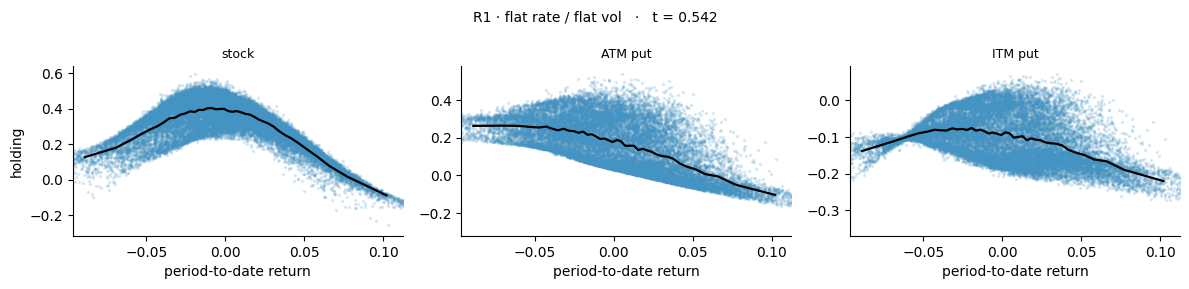

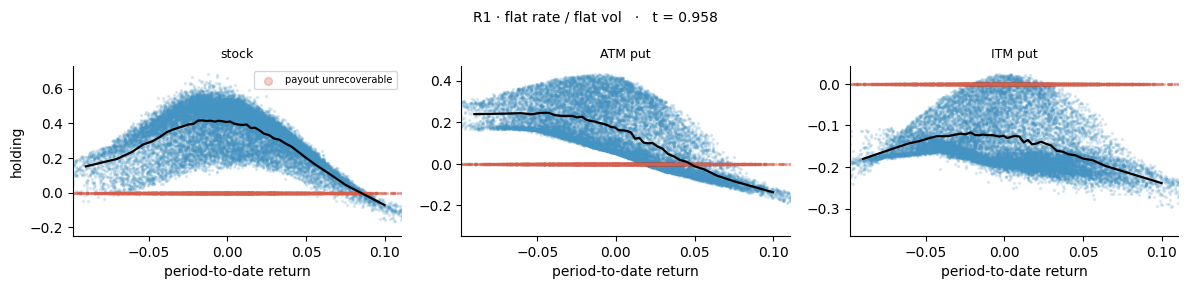

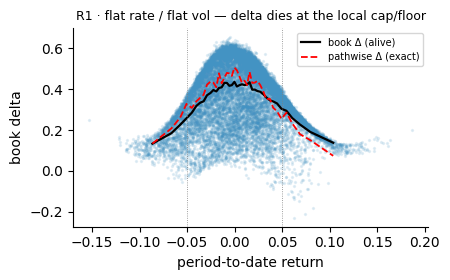

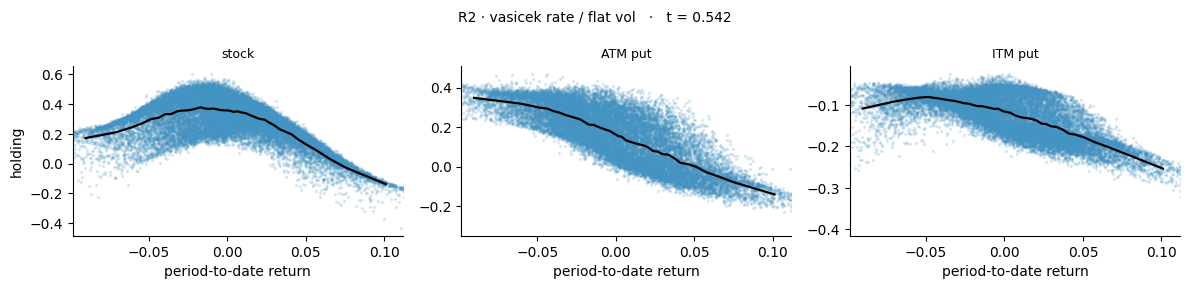

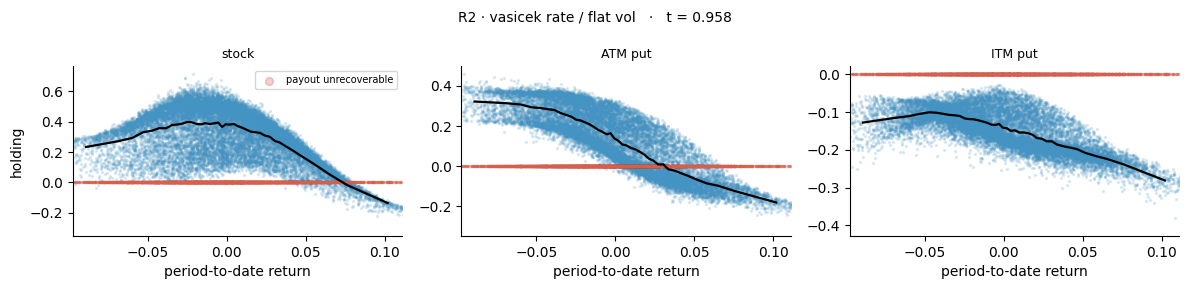

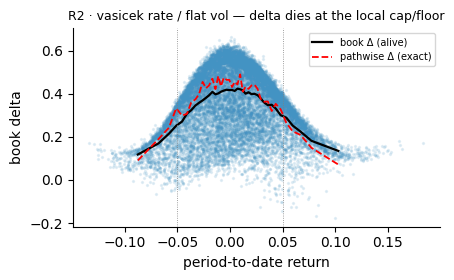

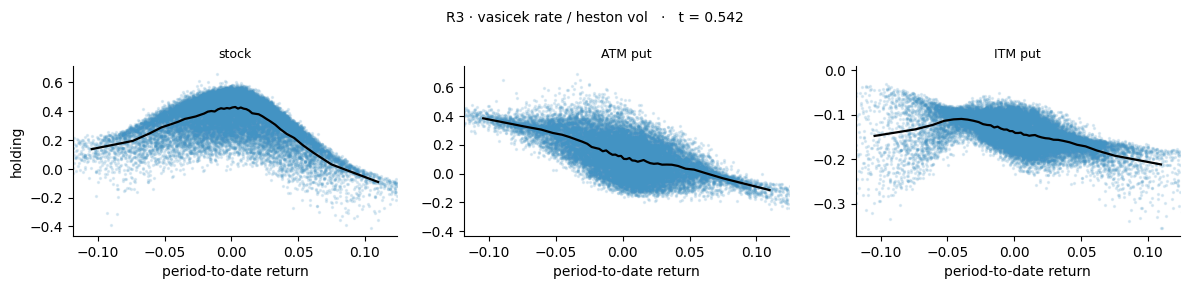

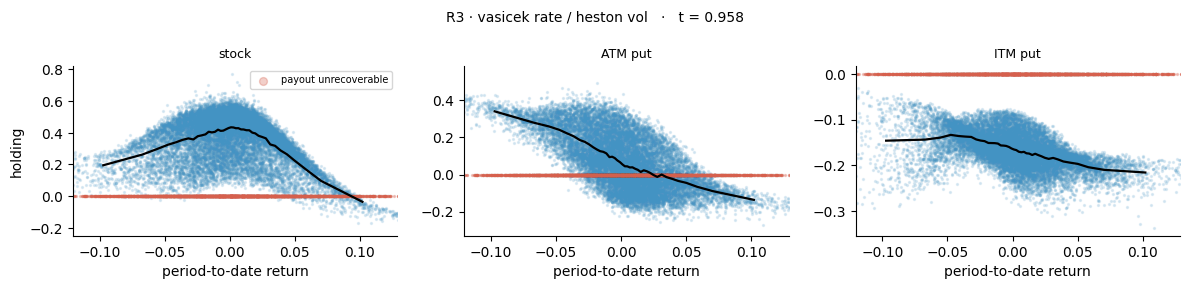

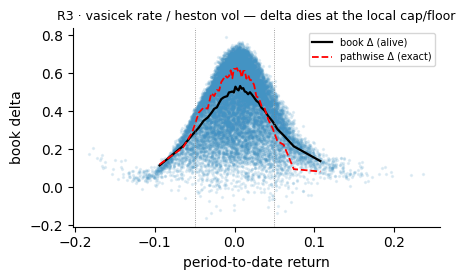

In [1]:
from qabit.core.products.derivatives.equity.cliquet import CliquetOption
from qabit.core.nn import PeriodReturn, CliquetLiveness

schedule, CAP, FLR = [k / 12 for k in range(1, 13)], 0.05, -0.05
T_clq, R_clq = 1.0, 0.03


def cliquet_state(res, k=None):
    """(period-to-date return, accumulated sum Y, exact pathwise book-delta ref, k)."""
    H = res.diag["holdings"]; k = H.shape[1] // 2 + 2 if k is None else k
    t = float(res.diag["open_times"][k]); dates = [0.0] + schedule
    last = max(d for d in dates if d <= t + 1e-9); j = dates.index(last)
    S = res.reg.stock.full_path(); d = res.reg.stock._state().dates
    ii = lambda v: int(torch.searchsorted(d, torch.tensor(v, dtype=d.dtype)))
    x = (S[:, ii(t)] / S[:, ii(last)] - 1).numpy()
    rets = torch.stack([S[:, ii(b)] / S[:, ii(a)] - 1 for a, b in zip(dates[:-1], dates[1:])], 1)
    Y = rets[:, :j].clamp(FLR, CAP).sum(1).numpy()
    tot = rets.clamp(FLR, CAP).sum(1); Rj = rets[:, j]
    pw = (math.exp(-R_clq * T_clq) * (tot > 0).float()
          * ((Rj > FLR) & (Rj < CAP)).float()
          * S[:, ii(dates[j + 1])] / (S[:, ii(last)] * S[:, ii(t)])).numpy()
    return x, Y, pw, k


dput = (lambda a: float(torch.distributions.Normal(0.0, 1.0).cdf(
    torch.tensor((math.log(1 / a) + (R_clq + 0.20**2 / 2) * (1 / 12)) / (0.20 * math.sqrt(1 / 12))))) - 1.0)
W = np.array([1.0, dput(1.00), dput(1.05)])
Norm = torch.distributions.Normal(0.0, 1.0)


def make_cliquet_prior(reg):
    """Structural prior: stock-leg holding = e^{-r(T-t)} x payout-gate(Y) x band-delta."""
    r_, sg = reg.r, reg.sigma
    def prior(ctx):
        s = ctx.spot(); dates = [0.0] + schedule
        last = max(d for d in dates if d <= ctx.t + 1e-9)
        nxt = min((d for d in dates if d > ctx.t + 1e-9), default=dates[-1])
        und = next(iter(ctx.target.underliers.values()))
        s_ref = und.spot(last).clamp(min=1e-12); tau = max(nxt - ctx.t, 1e-8)
        d1 = lambda K: (torch.log(s / (s_ref * K)) + (r_ + sg**2 / 2) * tau) / (sg * math.sqrt(tau))
        band = math.exp(r_ * tau) * (Norm.cdf(d1(1 + FLR)) - Norm.cdf(d1(1 + CAP))) / s_ref
        past = [d for d in dates if d <= last + 1e-9]; Y = torch.zeros_like(s)
        for a, b in zip(past[:-1], past[1:]):
            Y = Y + (und.spot(b) / und.spot(a).clamp(min=1e-12) - 1).clamp(FLR, CAP)
        gate = (Y + (len(dates) - len(past) + 1) * CAP > 0).to(s.dtype)
        out = torch.zeros(s.shape[0], 3, dtype=s.dtype, device=s.device)
        out[:, 0] = math.exp(-r_ * (T_clq - ctx.t)) * gate * band
        return out
    return prior


for rg, reg in REGIMES.items():
    legs, labels = make_legs(reg.stock, tenor=1 / 12)
    tgt = CliquetOption(reg.stock, schedule=schedule, local_cap=CAP, local_floor=FLR)
    res = hedge(reg, tgt, legs, make_features(reg, len(legs), extra=(PeriodReturn(),)),
                T=T_clq, rebal_dt=1 / 48, sim_dt=1 / 48, tenor=1 / 12,
                base_policy=make_cliquet_prior(reg), liveness=CliquetLiveness(), **BUDGET)
    results[("cliquet", rg)] = res
    x, Y, pw, k = cliquet_state(res)
    plot_vs(res, labels, x=x, xlabel="period-to-date return", k=k)
    kl = res.diag["holdings"].shape[1] - 2
    xl, Yl, _, kl = cliquet_state(res, k=kl)
    n_left = len(schedule) - sum(s <= float(res.diag["open_times"][kl]) + 1e-9 for s in schedule)
    dead = Yl + (n_left + 1) * CAP < 0
    plot_vs(res, labels, x=xl, xlabel="period-to-date return", k=kl, mask=dead,
            mask_label="payout unrecoverable")
    book = (res.diag["holdings"][:, k, :].numpy().T * W).sum(1)
    fig, ax = plt.subplots(figsize=(4.6, 2.9))
    ax.scatter(x[~dead], book[~dead], s=2, alpha=0.12, color="#4393c3", rasterized=True)
    ax.plot(*binned(x[~dead], book[~dead]), "k", lw=1.6, label="book Δ (alive)")
    ax.plot(*binned(x[~dead], pw[~dead]), "r--", lw=1.3, label="pathwise Δ (exact)")
    ax.axvline(CAP, color="gray", lw=0.6, ls=":"); ax.axvline(FLR, color="gray", lw=0.6, ls=":")
    ax.set_xlabel("period-to-date return"); ax.set_ylabel("book delta")
    ax.set_title(f"{reg.label} — delta dies at the local cap/floor", fontsize=9)
    ax.legend(fontsize=7); ax.spines[["top", "right"]].set_visible(False); plt.tight_layout()

## Lookback (fixed strike)

The payoff $\max(M_T-K,0)$ depends on the running max $M_t$. Once $M_t$ is far above
$S_t$ the intrinsic is locked and the option loses delta — so the right coordinate is
$\log(\max(M_t,K)/S_t)$, along which the holdings decay. The spread in the plain spot
cut is exactly the unplotted $M_t$.

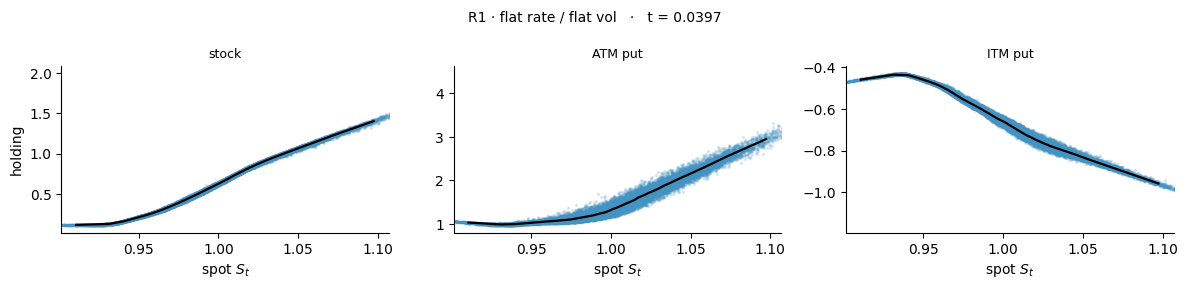

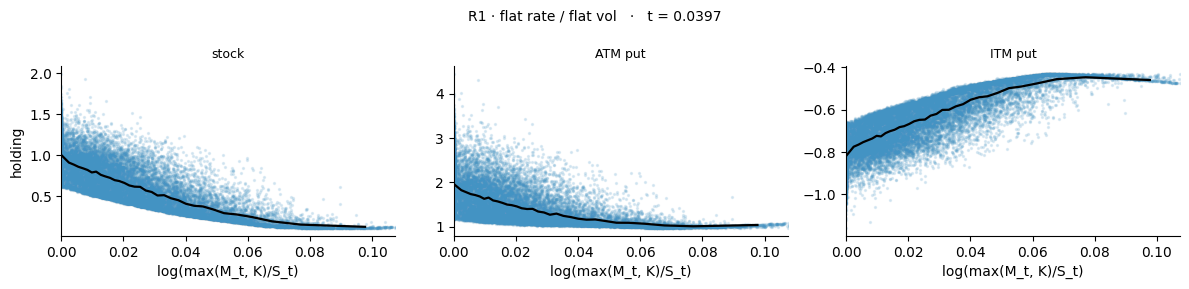

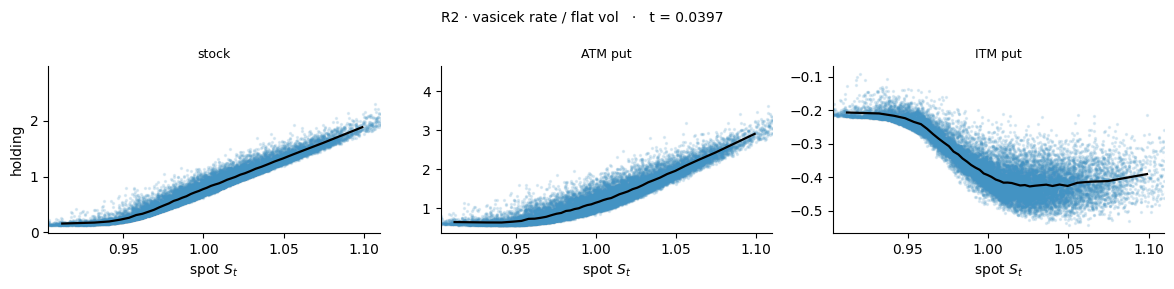

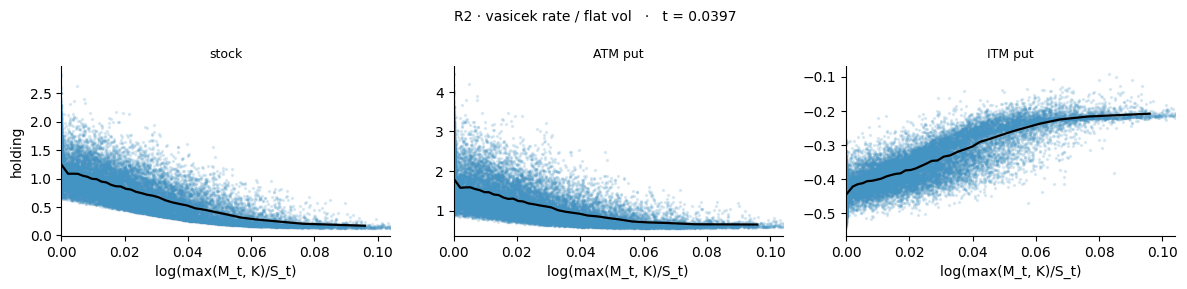

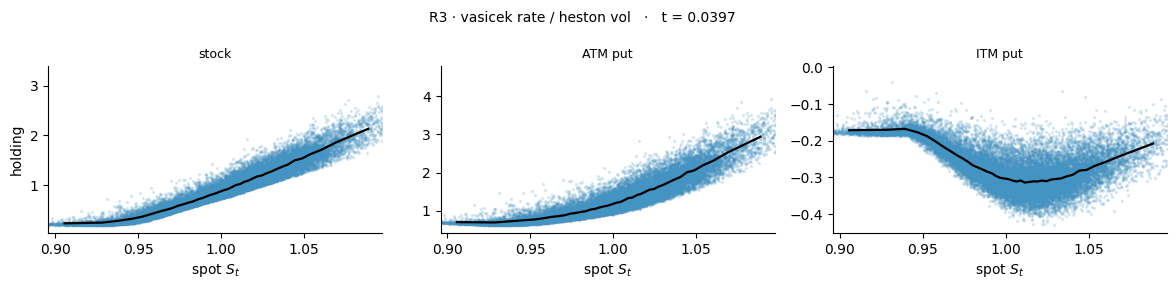

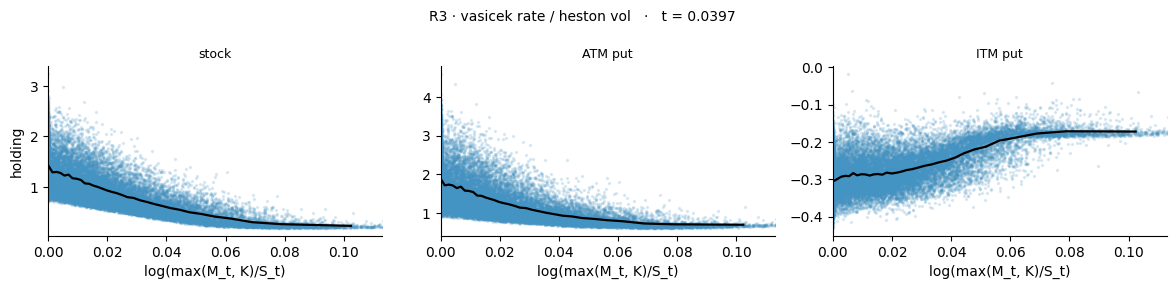

In [1]:
from qabit.core.products.derivatives.equity.lookback import FixedStrikeLookback

def lock_state(res, k=None):
    H = res.diag["holdings"]; k = H.shape[1] // 2 if k is None else k
    S = res.reg.stock.full_path(); d = res.reg.stock._state().dates
    i = int(torch.searchsorted(d, res.diag["open_times"][k].to(d.dtype)))
    M = S[:, : i + 1].max(1).values.numpy()
    return np.log(np.maximum(M, 1.0) / S[:, i].numpy()), k

T = 20 / 252
for rg, reg in REGIMES.items():
    legs, labels = make_legs(reg.stock)
    tgt = FixedStrikeLookback(reg.stock, strike=1.0, maturity=T, is_call=True)
    res = hedge(reg, tgt, legs, make_features(reg, len(legs)), T=T, **BUDGET)
    results[("lookback", rg)] = res
    plot_vs(res, labels)                                            # the cloud …
    x, k = lock_state(res)
    plot_vs(res, labels, x=x, xlabel="log(max(M_t, K)/S_t)", k=k)   # … explained